# GPT From Scratch - Arabic Poetry Model

This notebook covers Phase 1 (Pretraining) and Phase 2 (Supervised Fine-Tuning) of building a small GPT language model from scratch on Arabic poetry data.



## Step 0: Install Required Packages

In [2]:
!pip install torch torchvision torchaudio --quiet
!pip install transformers datasets tokenizers --quiet
!pip install matplotlib numpy tqdm --quiet
print(' All packages installed!')

 All packages installed!


In [23]:
!cp -r /content/checkpoints /content/drive/MyDrive/
!cp -r /content/data /content/drive/MyDrive/
!cp -r /content/results /content/drive/MyDrive/

## Step 1: Imports and Setup

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import json
import math
import os
import time
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'  Using device: {device}')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

  Using device: cuda
   GPU: Tesla T4


## Step 2: Phase 1 - Pretraining Data

We prepare a raw Arabic text corpus for pretraining. The goal is to teach the model the structure of the Arabic language using next token prediction.

In [4]:
# Arabic Poetry Pretraining Data (UTF-8 encoded)
# This is a curated sample of classical and modern Arabic poetry

arabic_poetry_pretrain = """قفا نبك من ذكرى حبيب ومنزل بسقط اللوى بين الدخول فحومل
وتوضح فالمقراة لم يعف رسمها لما نسجتها من جنوب وشمال
ترى بعر الأرآم في عرصاتها وقيعانها كأنه حب الفلفل
كأن فتات العهن في كل منزل نزلن به حب الفنا لم يحصل
ألا عم صباحا أيها الطلل البالي وهل يعمن من كان في العصر الخالي
وهل يعمن إلا سعيد مخلد قليل الهموم ما يبيت بأوجال
عرفت الديار كرقم الكتاب رقشه بنانان سعد وسعد العشيرة
ديار لسلمى إذ سلامى تجاورنا ومن دار سلمى خير من مر في الذكرى
أمن آل نعم أنت غاد فمبكر غداة غد أم رائح فمهجر
بزينب هذا الدمع ينهل منهمر وقلب بلوعات الصبابة مقعر
يا دار سلمى بالغميس فعاقل أقامت بها سلمى أمينة ذات دل
أحبك يا سلمى وقلبي مشتعل من الشوق والأحزان بالنار تشتعل
لك الله من معشوقة ما أجملك حللت من القلب المعذب منزلك
وقفت على ربع المحبة باكيا أسائله عمن أحب وقد خلا
ولم أر مثلي شاك بعد هجرها يبكي على ربع من الطين والحجر
تذكرت ليلى والسنين الخوالي وما بيننا من ود في تلك الليالي
وأيام لا نخشى على الحب رقيبا ولا نتقي إلا تصرم آجال
رضينا قسمة الجبار فينا لنا علم وللجهال مال
فإن المال يذهب حين يأتي وبقيا العلم ما بقيت الليالي
ولو أن الحياة تبقى لأحد لبكينا على الحياة بكاء
أبكي لو أن الدمع يجدي بكاؤه ويرجع ما أفنى الزمان اللياليا
رأيت الدهر يرفع كل قوم ويضع من علا في كل آن
فلا تفرح بدنيا زال عنها ولا تجزع من الدهر الخوان
البس لكل حالة لبوسها إما نعيمها وإما بؤسها
وإذا افتقرت فلا تكن متخشعا وترى الغنى في النفس خير من الغنى
صن النفس واحملها على ما يزينها تعش سالما والقول فيك جميل
وإن ضاقت الأحوال يوما فلا تضق فكل عسير يومه سيزول
أعلل نفسي بالتعلل والأمل وأسلو عن الدنيا بطيب التوكل
إلهي لا تؤاخذني بما قد بدا مني من الزلات في سالف العمر
وأنت الكريم العفو عن كل مذنب إذا جاء يبغي العفو بالذل والصبر
يا من له الملك والجبروت والكبرياء والعظمة والنور والضياء
أنت الذي بيده ملك السماء والأرض والمنتهى والابتداء
يا نفس ويحك لم تزال غافلة تسعين في اللهو الطويل الغادر
هذي المنايا دونها تترصدك والمرء لا يدري متى هو صائر
قل للمليحة في الخمار المذهب أفسدت زهد الناسك المتعبد
ردي علي فؤادي المسلوب قبل أن يمضي الجمال وتذوي الوردة والزند
أحبك يا وطني وروحك سارية في دمي كالشعر والأغاني
يا بلدي أنت الذي ملأ خيالي وعشت فيك وأنت روح الأماني
بلادي وإن جارت علي عزيزة وأهلي وإن شحوا علي كرام
وللموت خير من حياة ذليلة وللذل خير من وقوف على باب
هب الليل قد مد الجناح وأظلما وأومأ نجم الصبح أن يتقدما
فأقسمت لا أُلفى بغير كرامة فإما حياة تبتسم وتكرما
الشعر ديوان العرب فيه حياتهم وأخبارهم والمجد طول الدهور
بكل لسان يتلى الشعر عندهم ويبقى كما يبقى النسيم العطور
في القلب شعلة لا تنطفئ تضيء دروب الليل وتحيي الأمل
كلما اشتد الظلام تجلت وكلما طال الطريق استمر
سأظل أمشي في دروب الحياة وأحمل في قلبي شعلة الأحلام
ولن يثنيني ليل مهما اطال فالفجر يأتي بعد أصعب الظلام
أنا العربي ابن الصحارى والفنون لغتي قرآن وشعر وعيون
أفخر بتاريخي وأمجاد أجدادي وأسير بخطى ثابتة للأمام
يا أيها الليل الطويل ألا انجلي بصباح ذي وجه مضيء مكلل
ويا نسيم الفجر بلغ أحبتي شوقي إليهم أي شوق موصل
هذي بلادي في الخريف الجميل ألوانها تسبي العقول وتنير
النخل يرقص والرمال تناجي والشعر يجري كالجداول في النهر
قصيدتي يا أم حروفي الأولى وملجأ قلبي حين يعصف الألم
فيك أبوح بما يخنق في صدري وأنسى به وجع الزمان الأصم
مضى الشتاء وجاء الربيع يبشر والأرض تلبس ثوبا من الزهر
والطير يغني على الأغصان مبتهج والغيم يرحل بعد طول المطر
ما أجمل الدنيا إذا ما أشرقت شمس الصباح وانقشع الظلام
وأسمع الأطفال تضحك في الفجر وأرى الأمل يولد مع الأيام
كتبت على ورق الياسمين أشعاري وأرسلتها مع النسيم العطر
فيا من تقرأ ما كتبت سطوري اعرف أن الحب أصدق ما في الشعر
الحب بحر لا يشق له قرار ولا يبلغ أقصاه الغواص
يغرق فيه من لجج وما من نجاة إلا الرضا وسلامة الأنفاس
العلم نور والجهل ظلمة دامسة فاطلب العلم وكن للحق مدافعا
لا تقنع بالقليل وارفع همتك فالعلو مطلب كل نفس رافعة
من طلب العلى سهر الليالي وتجرع المر في طلب المعالي
ومن رام العلا من غير كد أضاع العمر في طلب المحال
يا طالب العلم لا تكسل ولا تنم فالمجد لا يدرك إلا بالسهر
واصبر على مر التعلم إنه أحلى من العسل في آخر المسير
للصبر مفتاح الفرج وبعد الضيق يأتي الفرج
ومن يصبر على الأذى يبلغ ما يرجو من العلا والدرج
قالت الحكمة للعاقل اسمع واجعل لسانك رهين الصمت إذ تسمع
فرب كلمة ندم قائلها وصمت أفصح من ألف حجة تُسمع
الصدق منجاة وإن خفت وطأته والكذب مهلكة وإن زخرف
كن صادقا في القول والفعل معا فالصدق أساس كل خير يُنتظف
يا دار بالعلياء كم ليلة درسنا وكم من علم فيك تلقينا
رحلنا عنك لكن الذكريات بقيت تسكن في الأعماق وتحيينا
أيام المدرسة أحلى الأيام وأصفى والزمان الجميل
حين كنا نلعب في الملاعب والأحلام بيضاء كالنهر الأصيل
يا صاحبي هذا الزمان يمر وكل لقاء يعقبه الفراق
فاغتنم صحبة الأخيار في حياتك فالعمر يمضي والأيام تستبق
الصحبة الطيبة كنز لا يُقدر وزاد المسافر في طريق النجاح
خذ الأصحاب الأخيار وكن معهم فهم خير ما تطلبه في الفلاح
كفى بالمرء نبلا أن تُعد معايبه والناقص من عُدت فضائله
فلا تطلب الكمال في كل أحد فلا إنسان في الدنيا يخلو من خلل
عامل الناس كما تحب أن يعاملوك وافعل الخير دائما وإن لم يُشكر
فالجزاء من جنس العمل وزرع الخير يجني ثماره في الغد والحاضر
أيا دنيا ألا تفني غرورك لقد أخدعت بالوهم كل مغرور
زخارفك تفنى وتبقى المعاصي والمآثر شاهدة على كل مسرور
الموت حق وما الحياة بدائمة وكل نفس ستذوق كأسه البكور
فاعمل لآخرتك ودع عنك زخرفا فما الدار إلا دار حق وثبور"""

# Save pretraining data
os.makedirs('data/pretrain', exist_ok=True)
with open('data/pretrain/data.txt', 'w', encoding='utf-8') as f:
    f.write(arabic_poetry_pretrain)

# Stats
lines = arabic_poetry_pretrain.strip().split('\n')
print(f' Pretraining data saved!')
print(f'   Lines: {len(lines)}')
print(f'   Characters: {len(arabic_poetry_pretrain)}')
print(f'   Words: {len(arabic_poetry_pretrain.split())}')
print(f'\n Sample (first 3 lines):')
for l in lines[:3]:
    print(f'   {l}')

 Pretraining data saved!
   Lines: 92
   Characters: 4839
   Words: 934

 Sample (first 3 lines):
   قفا نبك من ذكرى حبيب ومنزل بسقط اللوى بين الدخول فحومل
   وتوضح فالمقراة لم يعف رسمها لما نسجتها من جنوب وشمال
   ترى بعر الأرآم في عرصاتها وقيعانها كأنه حب الفلفل


## Step 3: Phase 2 - SFT Fine-tuning Data

We prepare 200 instruction-response pairs for supervised fine-tuning. These cover poetry generation, completion, translation and explanation tasks.

In [5]:
# SFT Data: 200 instruction-response pairs for Arabic poetry tasks
sft_data = [
    {"instruction": "اكتب بيتاً شعرياً عن الحب", "input": "", "output": "أحبك حباً لو علمت به لذاب جوى قلب يُسيل الشعرا"},
    {"instruction": "اكتب بيتاً شعرياً عن الوطن", "input": "", "output": "بلادي وإن جارت علي عزيزة وأهلي وإن شحوا علي كرام"},
    {"instruction": "اكتب قصيدة قصيرة عن الأمل", "input": "", "output": "لا تيأسن فبعد الليل صبح مشرق\nوبعد الكرب يأتي الفرج والفلح\nتصبر على مر الحياة فإنها\nتزول وما بعد الشدائد إلا المنح"},
    {"instruction": "أكمل هذا البيت الشعري", "input": "قفا نبك من ذكرى حبيب ومنزل", "output": "بسقط اللوى بين الدخول فحومل"},
    {"instruction": "اشرح معنى هذا البيت الشعري", "input": "بلادي وإن جارت علي عزيزة", "output": "يعبر الشاعر عن حبه العميق لوطنه حتى لو ظلمه أو آذاه فالوطن يبقى غالياً على قلبه مهما كانت الظروف"},
    {"instruction": "اكتب بيتاً عن الصداقة", "input": "", "output": "صديق الخير خير الناس طراً وخير الزاد زاد في التقى"},
    {"instruction": "اكتب شعراً عن الليل", "input": "", "output": "يا أيها الليل الطويل ألا انجلي\nبصباح ذي وجه مضيء مكلل\nكم بت أرعى النجم أبكي وأشتكي\nوأنوح شوقاً للحبيب المرحل"},
    {"instruction": "اكتب بيتاً عن الصبر", "input": "", "output": "اصبر على مر الزمان فربما يجني الصبور ثمار صبره في الغد"},
    {"instruction": "اكتب قصيدة تمدح فيها العلم", "input": "", "output": "العلم نور يضيء دروب الحياة\nويرفع أهله في كل آن\nفاطلب العلم ولو في الصين بعيداً\nففي العلم مفتاح كل الأوطان"},
    {"instruction": "ترجم هذا البيت إلى الإنجليزية", "input": "العلم نور والجهل ظلام", "output": "Knowledge is light and ignorance is darkness"},
    {"instruction": "اكتب بيتاً عن الأم", "input": "", "output": "الأم جنة في الحياة ونعمة وحضنها أمان لكل حزين"},
    {"instruction": "اكتب شعراً عن الربيع", "input": "", "output": "جاء الربيع بثوب من الزهر منسوج\nوالطير يشدو والجداول تغني\nوالأرض تحيا بعد موت الشتاء\nوينبت الأمل في كل ركن وزاوية"},
    {"instruction": "اكتب بيتاً عن الشجاعة", "input": "", "output": "لا تخش في الحق لومة لائم فالحق أحق أن يقال ويُدافع"},
    {"instruction": "اكتب قصيدة عن النجوم", "input": "", "output": "يا نجوم السماء كيف تضيئين\nوتغنين لمن بعيد تحن\nأنتم شهود الليل والسر تعلمن\nومصابيح للتائهين تكن"},
    {"instruction": "اكتب بيتاً عن الغربة", "input": "", "output": "أقيم في الغربة جسماً وفي الوطن روحي تسكن حيث شب المهد"},
    {"instruction": "ما الوزن الشعري المستخدم في الطويل", "input": "", "output": "بحر الطويل يقوم على تفعيلة فعولن مفاعيلن وتتكرر أربع مرات في الشطرة الواحدة"},
    {"instruction": "اكتب شعراً عن البحر", "input": "", "output": "يا بحر كم في أعماقك من أسرار\nوكم موجة أودت بأرواح كبار\nلكنك تبقى رمزاً للحرية والعطاء\nوملجأ الشعراء في الليل والنهار"},
    {"instruction": "اكتب بيتاً عن الزمن", "input": "", "output": "يمر الزمان كلمح البصر فما أسرع الليل يعقبه الفجر"},
    {"instruction": "اكتب قصيدة عن الطفولة", "input": "", "output": "يا زمن الطفولة يا جنة الأحلام\nحين كانت الدنيا بسمة وألعاب\nأيام مضت ولم تعد مثلها أيام\nوبقيت ذكراها جرحاً في الأوتار"},
    {"instruction": "اكتب بيتاً عن الحكمة", "input": "", "output": "الحكمة ضالة المؤمن فخذها حيث وجدتها ولو من فم الزمن"},
    {"instruction": "اكتب شعراً عن الفراق", "input": "", "output": "الفراق جرح في القلب لا يبرأ\nودمعة تجري على الخد لا تجف\nيا من رحلت وتركت قلباً موجعاً\nهل تدري كم أشتاقك في الصحو والشغف"},
    {"instruction": "اكتب بيتاً عن الإيمان", "input": "", "output": "توكلت على الله في كل أمرتي فيا حسن ما أرجو ويا طيب ما أملا"},
    {"instruction": "صف الصحراء شعراً", "input": "", "output": "الصحراء ملكة في ثوب من رمال\nوصمتها أبلغ من ألف مقال\nتحمل في صدرها أسرار الأجداد\nوتروي قصص العرب في الليالي الطوال"},
    {"instruction": "اكتب بيتاً عن الكتاب", "input": "", "output": "الكتاب خير جليس في الزمان فصاحبه يرقى ويسمو شأنا"},
    {"instruction": "اكتب شعراً عن المطر", "input": "", "output": "نزل المطر فأحيا الأرض بعد موات\nوغسل التراب من غبار السنوات\nهكذا الأمل ينزل على القلوب\nفيحيي ما مات من آمال وأمنيات"},
    {"instruction": "اشرح بحر الكامل", "input": "", "output": "بحر الكامل هو أكثر بحور الشعر العربي استخداماً وتفعيلته متفاعلن تتكرر ست مرات في البيت الكامل"},
    {"instruction": "اكتب بيتاً عن الشمس", "input": "", "output": "تشرق الشمس فيحيا الكون بالنور ويغني الطير في الأشجار مسروراً"},
    {"instruction": "اكتب قصيدة مدح", "input": "المملكة العربية السعودية", "output": "يا أرض الحرمين والمجد الأثيل\nحيث تلتقي الأرواح بالأمل الجميل\nأرض الأجداد والتاريخ والعزة\nومهبط الوحي في كل ليل وقيل"},
    {"instruction": "اكتب بيتاً عن القهوة", "input": "", "output": "في قلبي سكنت يا قهوة الفجر ورائحتك تملأ الأرجاء عطراً"},
    {"instruction": "ما الفرق بين الشعر العمودي والتفعيلة", "input": "", "output": "الشعر العمودي يلتزم بالوزن والقافية في كل بيت بينما شعر التفعيلة يحافظ على التفعيلة الأساسية دون إلزام القافية الثابتة"},
    {"instruction": "اكتب شعراً عن الأنهار", "input": "", "output": "النهر يجري لا يعرف الوقوف\nيهمس للضفاف أغاني الشوق والخوف\nحتى يصل للبحر محقق حلمه\nوهكذا الإنسان يسعى لما يألوف"},
    {"instruction": "اكتب بيتاً في رثاء شخص عزيز", "input": "", "output": "رحلت وبقيت وحيداً في الدنيا أبكي وأشكو للنجوم الغياب"},
    {"instruction": "اكتب أبياتاً عن العدل", "input": "", "output": "العدل أساس الملك والبنيان\nوبه يزدهر الوطن والإنسان\nفاحكم بالعدل في كل أمر\nففي العدل سلامة الأجيال والأزمان"},
    {"instruction": "اكتب بيتاً عن الجود والكرم", "input": "", "output": "من جاد بالمال اشترى الحب والثناء ومن شح فقد ضيع العمر هباء"},
    {"instruction": "صف الغروب شعراً", "input": "", "output": "حين تغرب الشمس يتلون الأفق\nبألوان الذهب والبرتقال والشفق\nكأن السماء تودع يومها بدموع\nمن خجل الجمال قبل أن يغتفق"},
    {"instruction": "اكتب بيتاً عن الوفاء", "input": "", "output": "الوفاء تاج الرجال وزينتهم ومن خانه يوماً فقد ضيع قيمته"},
    {"instruction": "اكتب شعراً عن الأشجار", "input": "", "output": "الشجرة تعطي في الصيف ظلالها\nوتهب للعابر هواءها وثمارها\nفكن مثلها يا إنسان في حياتك\nأعط ولا تنتظر الجزاء وأبقى أثارها"},
    {"instruction": "اكتب بيتاً عن الرحلة", "input": "", "output": "يا مسافر الدنيا لا تنس أن الرحلة تنتهي ولكل سفر منتهى"},
    {"instruction": "اكتب قصيدة قصيرة عن الغيم", "input": "", "output": "الغيم في السماء كالأحلام تسبح\nيحمل في جوفه وعداً بالمطر\nويمشي بخطى الرياح لا يستقر\nحتى يفيض في لحظة ويبتسم البشر"},
    {"instruction": "اكتب بيتاً عن القمر", "input": "", "output": "يا قمر الليل أنت سر اللياليحين يغيب الشمس وتنام الأماني"},
    {"instruction": "اكتب شعراً عن الحرية", "input": "", "output": "الحرية أغلى من الذهب والجواهر\nوأرفع من كل تاج وعروش\nمن ذاق طعمها لا يرضى سواها\nولو كلفته الأرواح والنفوس"},
    {"instruction": "اكتب بيتاً عن الخير", "input": "", "output": "افعل الخير في حياتك فبعد الموت لا يبقى غير ما فعلت من خير"},
    {"instruction": "صف الليل الهادئ شعراً", "input": "", "output": "الليل ساكن والنجوم تلألأت\nوالقمر يسبح في بحر السكون\nفنمت الأحزان وصحا الأمل\nوفي الهدوء تولد الأحلام والفنون"},
    {"instruction": "اكتب بيتاً عن الذاكرة", "input": "", "output": "ذاكرتي كنز من الماضي العزيز فيها صور الأحبة والأيام الجميلة"},
    {"instruction": "اكتب شعراً عن الأمل في المستقبل", "input": "", "output": "المستقبل يناديني بصوت الأمل\nوالغد يحمل ما لم يحمله الأمس\nفامش إليه بخطى ثابتة واثقة\nفأنت أجدر بالنجاح من كل يأس"},
    {"instruction": "اكتب بيتاً عن اللقاء", "input": "", "output": "اللقاء بعد الفراق نعمة وبهجة تشفي ما في القلوب من ألم"},
    {"instruction": "اكتب قصيدة عن الشعر نفسه", "input": "", "output": "الشعر روح الكلام ونبضه\nوبه تحيا اللغات وتعيش\nمن قال شعراً خلد اسمه\nومن لم يقله عاش وعاش"},
    {"instruction": "اكتب بيتاً عن الجمال", "input": "", "output": "الجمال ليس في الوجوه وحدها بل في الأخلاق والمعادن الطيبة"},
    {"instruction": "اكتب شعراً عن الصحة", "input": "", "output": "الصحة تاج على رؤوس الأصحاء\nلا يراه إلا المرضى والضعفاء\nفاحرص عليها واشكر الله عليها\nفهي أثمن عطاء بين عطاء"},
    {"instruction": "اكتب بيتاً في وصف العيون", "input": "", "output": "عيناك بحران من السحر والجمال من نظر إليهما غرق في الخيال"},
    {"instruction": "اكتب شعراً عن الوقت", "input": "", "output": "الوقت سيف فاقطعه قبل أن يقطعك\nوزرع في حقله ما تريد أن تحصده\nيمر كالسهم لا يعود وراءه\nفاغتنم لحظاته تسعد بعيدك وعهده"},
    {"instruction": "اكتب أبياتاً في ذم الكذب", "input": "", "output": "الكذب داء يفتك بصاحبه\nويهدم ما بنى من ثقة وأمان\nلا تكذب ولو اشتد عليك البلاء\nفالصدق طريق العز والإيمان"},
    {"instruction": "اكتب بيتاً عن الشتاء", "input": "", "output": "الشتاء جاء بمطر وببرد وبرياح لكنه يحمل للأرض الحياة والبشر"},
    {"instruction": "اكتب قصيدة وصفية عن التمر", "input": "", "output": "التمر درة الصحراء ونعمة السماء\nأثقل النخلة بكل الأشواق\nفي حبته حلاوة وشفاء\nوعلى المائدة سيد الأذواق"},
    {"instruction": "اكتب بيتاً يحث على التفاؤل", "input": "", "output": "تفاءل بالخير تجده فما ضاق على المتفائل أمر أبدا"},
    {"instruction": "اكتب شعراً عن الجبال", "input": "", "output": "الجبال شامخة في كبرياء\nتتحدى العواصف والأعداء\nفكن مثل الجبل شامخاً ثابتاً\nولا تنحني أمام قسوة الأقدار"},
    {"instruction": "اكتب بيتاً عن الوالدين", "input": "", "output": "بر الوالدين جنة في الدنيا فأكرمهما يكرمك الله وترقى"},
    {"instruction": "اكتب قصيدة تهنئة بالعيد", "input": "", "output": "عيد مبارك يا أهل الكرم والعطاء\nجاء العيد يبشر بالفرح والسعادة\nفليهنأ القلب ويبتسم الوجه\nويعيش الجميع أياماً بلا نكد ولا شكاوى"},
    {"instruction": "اكتب بيتاً عن الحرف والعمل", "input": "", "output": "الحرفة عز وكرامة فمن عمل بيديه ارتفع وعلا شأنه"},
    {"instruction": "اكتب شعراً وصفياً لحديقة", "input": "", "output": "في الحديقة تتفتح الورود بالأحمر والأصفر والأبيض الجميل\nوالطير يرفرف بين الأغصان\nوعطر الزهر يملأ المكان بالجميل"},
    {"instruction": "اكتب بيتاً عن الدعاء", "input": "", "output": "ارفع يديك إلى الله بالدعاء فإنه السميع المجيب عند الرجاء"},
    {"instruction": "اكتب قصيدة في مدح الشجاع", "input": "", "output": "يا من خاض معارك الحق بلا خوف\nوقاتل الظلم بسيف الصدق والعدل\nأنت قدوة الأبطال في كل زمان\nوسيذكرك التاريخ بأجمل الفصل"},
    {"instruction": "اكتب بيتاً عن العقل", "input": "", "output": "العقل تاج الإنسان وزينته فمن استعمله رقى ومن أهمله ضاع"},
    {"instruction": "اكتب شعراً عن الحنين", "input": "", "output": "أحن إلى الوطن حنين الغريب\nوأشتاق للأهل شوق الحبيب\nيا موطني يا حلم الليالي\nمتى أعود إليك قريب"},
    {"instruction": "اكتب بيتاً عن السلام", "input": "", "output": "السلام أغلى الأمنيات فلا يهنأ من عاش في الخوف والحروب"},
    {"instruction": "اكتب أبياتاً عن الهمة العالية", "input": "", "output": "ارفع همتك وحلق في سماء الطموح\nفالنجوم لمن يسعى إليها ويصل\nلا تقف عند الصغائر متردداً\nبل اقتحم آفاق المجد وتوصل"},
    {"instruction": "اكتب بيتاً عن الغفران", "input": "", "output": "اعف عمن أساء إليك فالعفو شيمة الكرام وخير ما يلبسه الإنسان"},
    {"instruction": "اكتب قصيدة في وصف الفجر", "input": "", "output": "الفجر نور يولد من رحم الليل\nويبشر بيوم جديد مشرق جميل\nتستيقظ الطيور وتغني النسيمات\nويتجدد الأمل مع كل فجر أصيل"},
    {"instruction": "اكتب بيتاً عن الصدق", "input": "", "output": "الصدق سيف لا يصدأ ومن تسلح به في الحياة ظفر بكل خير"},
    {"instruction": "اكتب شعراً عن الخريف", "input": "", "output": "الخريف يرسم على الأشجار لوحة\nبألوان الذهب والنحاس والزيتون\nتتساقط الأوراق كأنها دموع\nتودع صيفاً مضى بين الأغصون"},
    {"instruction": "اكتب بيتاً في وصف النهر", "input": "", "output": "النهر يجري بين ضفتين في هدوء كالعاقل يسير في الحياة دون صخب"},
    {"instruction": "اكتب أبياتاً عن التضحية", "input": "", "output": "التضحية شرف لمن أهل لها\nويختار الكرام الفداء على الهوان\nمن ضحى من أجل الحق انتصر\nومن آثر الراحة عاش في الأحزان"},
    {"instruction": "اكتب بيتاً عن الطيور", "input": "", "output": "الطيور تغني للحياة وتبشر بالخير وكذلك الإنسان يحيا بالأمل والتعبير"},
    {"instruction": "اكتب قصيدة قصيرة عن الحب الصادق", "input": "", "output": "حبك صادق لا يشبه الأوهام\nوفي قلبي له وطن وإقامة\nلن أبحث عن غيرك في الدنيا\nفأنت أجمل ما في الحياة وأمانة"},
    {"instruction": "اكتب بيتاً عن العطاء", "input": "", "output": "أعط ولا تمن بما أعطيت فالكرم شيمة من رزق الله واسع"},
    {"instruction": "اكتب شعراً عن الذكريات الجميلة", "input": "", "output": "ذكريات الماضي كالنجوم في الليل\nتضيء في الظلام وتبقى في الذاكرة\nكلما غبت عنها اشتقت إليها\nوكلما عدت إليها كانت أجمل وأغلى"},
    {"instruction": "اكتب بيتاً عن الانتصار", "input": "", "output": "من صبر على الشدائد وصمد في وجه العواصف خرج منتصراً بالغار"},
    {"instruction": "اكتب أبياتاً عن المرأة العربية", "input": "", "output": "المرأة العربية تاج الحضارة\nوأم الرجال وصانعة الأجيال\nعطاؤها بلا حدود وصبرها جبال\nوفي ابتسامتها تكمن كل الآمال"},
    {"instruction": "اكتب بيتاً عن اللغة العربية", "input": "", "output": "اللغة العربية كنز من ذهب وعقيق فصاحتها تسبي العقول وتشفي القلوب"},
    {"instruction": "اكتب قصيدة وطنية", "input": "", "output": "يا وطني أنت الحياة والهواء\nوفي ترابك دفن الأجداد والآباء\nأموت في حبك ولا أحيا ذليلاً\nفالشهادة في سبيلك أجمل لقاء"},
    {"instruction": "اكتب بيتاً عن الجود", "input": "", "output": "جود الكريم لا ينضب كالبحر العميق ومن جاد بماله اشترى الحب الرفيق"},
    {"instruction": "اكتب شعراً عن السفر", "input": "", "output": "السفر يفتح أمام الإنسان أبواباً\nمن المعرفة والخبرة والفهم\nكن مسافراً في الأرض تتعلم\nفمن جلس في مكانه لم يفهم"},
    {"instruction": "اكتب بيتاً عن الفرح", "input": "", "output": "الفرح نور في القلوب ونعمة من الله لا يقدرها إلا من حرم منها"},
    {"instruction": "اكتب قصيدة قصيرة عن النجاح", "input": "", "output": "النجاح ثمرة الجد والاجتهاد\nولا ينال المجد بالكسل والرقاد\nمن أراد النجوم فليسع إليها\nفالنجوم لمن اجتهد وجاهد"},
    {"instruction": "اكتب بيتاً عن الزهرة", "input": "", "output": "الزهرة تتفتح وتضوع بالعطر ثم تذبل وتمضي كعمر الإنسان"},
    {"instruction": "اكتب أبياتاً في مدح العقلاء", "input": "", "output": "العقلاء هم نور المجتمع وسراجه\nيسيرون بالحكمة والرأي السديد\nيزنون الأمور بميزان العدل\nويبنون الحضارة بالعلم الرشيد"},
    {"instruction": "اكتب بيتاً عن ضيق الصدر", "input": "", "output": "يا رب إن ضاق بي الأمر وضاقت الدنيا فافتح لي من رحمتك بابا"},
    {"instruction": "اكتب شعراً عن رمضان", "input": "", "output": "رمضان جاء بنور وبركة\nوملأ القلوب بالإيمان والتقى\nشهر القرآن والصيام والدعاء\nفلنغتنمه قبل أن يمضي ويخلى"},
    {"instruction": "اكتب بيتاً عن الورد", "input": "", "output": "الورد يبسم للضيف حين يأتي ويهدي عطره للعابر والمقيم"},
    {"instruction": "اكتب قصيدة عن التسامح", "input": "", "output": "التسامح شجرة تثمر المحبة\nوتحيل الأعداء إلى إخوان\nامح ما كان وابدأ صفحة بيضاء\nفالتسامح أسمى ما بين الإنسان"},
    {"instruction": "اكتب بيتاً عن الطموح", "input": "", "output": "لا تطمح لما دون النجوم فالعالي يناله من سعى وطمح"},
    {"instruction": "اكتب شعراً عن الأجداد", "input": "", "output": "يا أجدادي أنتم مفخرتنا\nوفي سيرتكم نجد الطريق المستقيم\nعلمتمونا الشجاعة والكرم\nوتركتم لنا إرثاً من العلم العظيم"},
    {"instruction": "اكتب بيتاً عن العدو", "input": "", "output": "العدو الحاقد يدفعك للأمام فكن شاكراً له لأنه علمك الصمود"},
    {"instruction": "اكتب قصيدة قصيرة عن المدينة", "input": "", "output": "المدينة تنبض بالحياة والحركة\nوالبشر فيها يتنافسون ويسعون\nلكن بين ضجيجها ثمة وحدة\nيحس بها من في الزحام يعيشون"},
    {"instruction": "اكتب بيتاً عن الهواء", "input": "", "output": "الهواء نعمة لا نشعر بها حتى تنقطع فاحمد الله على كل نفس تستنشق"},
    {"instruction": "اكتب أبياتاً عن الصيام", "input": "", "output": "الصيام تزكية للروح والجسد\nويعلم الإنسان الصبر والجلد\nاصبر على الجوع ساعات قليلة\nثم انعم بإفطار يكافئ الجهد"},
    {"instruction": "اكتب بيتاً عن البسمة", "input": "", "output": "البسمة صدقة وهي أجمل ما في الوجه البشوش وأبلغ من كل خطاب"},
    {"instruction": "اكتب شعراً عن الكرامة", "input": "", "output": "لا تبع كرامتك بثمن مهما كان\nفالكرامة لا تشترى ولا تباع\nصن نفسك عن الهوان والذل\nففي الكرامة الشرف ورأس المتاع"},
    {"instruction": "اكتب بيتاً عن الإحسان", "input": "", "output": "أحسن إلى الناس كي تنام هانئاً والإحسان يعود على صاحبه بضعف"},
    {"instruction": "اكتب قصيدة وصفية عن الخيل", "input": "", "output": "الخيل مجد وكرامة وجمال\nتجري كالريح بين الفيافي والجبال\nهي رفيق الفارس في ميادين الوغى\nورمز العز والشهامة للرجال"},
    {"instruction": "اكتب بيتاً عن الغنى الحقيقي", "input": "", "output": "الغنى غنى النفس لا غنى المال والأموال تفنى والقناعة لا تفنى"},
    {"instruction": "اكتب شعراً عن التاريخ العربي", "input": "", "output": "يا أمة العرب أين مجد أجدادك\nأين ابن بطوطة وسيناء وابن رشد\nأيام كانت بغداد قلب العالم\nوأندلس منارة الحضارة والرشد"},
    {"instruction": "اكتب بيتاً عن الغضب", "input": "", "output": "احفظ لسانك عند الغضب فرب كلمة في لحظة هدمت ما بنته سنون"},
    {"instruction": "اكتب أبياتاً تحث على طلب العلم", "input": "", "output": "اطلب العلم ولو في الصين بعيداً\nفالعلم لا وطن له ولا حدود\nكن متعلماً طوال حياتك\nفالعلم بحر لا ينضب وكنوز"},
    {"instruction": "اكتب بيتاً عن الحكيم", "input": "", "output": "الحكيم من يستشير ثم يفعل بعد التمحيص والحكيم لا يتسرع"},
    {"instruction": "اكتب قصيدة عن الأنثى الصالحة", "input": "", "output": "المرأة الصالحة كنز لصاحبها\nتسعده في الشدة والرخاء\nتبني البيت على أعمدة من حب\nوتربي الأجيال على العلا"},
    {"instruction": "اكتب بيتاً عن الظلم", "input": "", "output": "الظلم لا يدوم والظالم يُحاسب يوماً فلا تظلم أحداً ولا تقبل الظلم"},
    {"instruction": "اكتب شعراً عن الحياة الريفية", "input": "", "output": "في القرية تعيش الروح بسلام\nوالهواء نقي والماء من الينبوع\nالحياة هناك بسيطة وصادقة\nبعيدة عن ضجيج المدينة والرجوع"},
    {"instruction": "اكتب بيتاً في وصف الفروسية", "input": "", "output": "الفارس العربي شرف وعزة فوق صهوة جواده يصنع الأمجاد"},
    {"instruction": "اكتب قصيدة قصيرة في حب الرسول", "input": "", "output": "يا نبي الله أنت النور والهدى\nوفي سيرتك قدوة ومنهج ودى\nأحبك يا رسول الله في القلب\nوأرجو شفاعتك في اليوم الأصعد"},
    {"instruction": "اكتب بيتاً عن الكبرياء الزائف", "input": "", "output": "لا تتكبر على الناس فالكبرياء جلباب الضعيف الذي يخشى الحقيقة"},
    {"instruction": "اكتب شعراً عن الموج", "input": "", "output": "الموج يصطدم بالصخر ولا ييأس\nويعود مرة وأخرى بلا كلل\nفكن مثل الموج في إصراره\nوتحطم أمامك كل حاجز وأزل"},
    {"instruction": "اكتب بيتاً عن التواضع", "input": "", "output": "التواضع شرف والكبرياء نقيصة فالمتواضع يرفعه الله والمتكبر يذل"},
    {"instruction": "اكتب أبياتاً عن الشهداء", "input": "", "output": "الشهداء أحياء عند ربهم\nسقوا الأرض بدمائهم الزاكية\nفلن ننسى تضحياتهم أبداً\nوسنحمل رايتهم راية عالية"},
    {"instruction": "اكتب بيتاً عن طلوع الشمس", "input": "", "output": "يا شمس الصباح حين تشرقين تبعثين في النفوس الأمل والحياة"},
    {"instruction": "اكتب قصيدة عن الذهب", "input": "", "output": "الذهب بريق يخدع الأعين\nوكم أغرى الناس فضل وخسر\nالأخلاق الحميدة أغلى من الذهب\nوالإنسان النبيل أثمن ما يُعتبر"},
    {"instruction": "اكتب بيتاً عن الحياة البسيطة", "input": "", "output": "من قنع بالقليل عاش راضياً سعيداً ومن طمع في الكثير عاش تعيساً مهموماً"},
    {"instruction": "اكتب شعراً عن المصير", "input": "", "output": "كل نفس ستعود يوماً إلى ربها\nوتحاسب على ما قدمت وأخرت\nفاعمل في الدنيا لآخرتك\nوازرع الخير في الدنيا كي تجنيه ورت"},
    {"instruction": "اكتب بيتاً عن الكون", "input": "", "output": "الكون كتاب الله المفتوح تقرأ فيه آيات العظمة والجلال"},
    {"instruction": "اكتب أبياتاً عن الوفاء بالعهد", "input": "", "output": "من وعد فليوف وإلا فليصمت\nالوعد دين على الرجل الكريم\nمن أخلف الوعد سقط في نظر الناس\nولا يستوي الخائن والمستقيم"},
    {"instruction": "اكتب بيتاً عن الأنوار", "input": "", "output": "نور العقل أبقى من نور الشمعة ونور العلم يضيء في الظلام الدامس"},
    {"instruction": "اكتب قصيدة عن التراب", "input": "", "output": "يا تراب الوطن أنت طهر وقداسة\nمنك خلقنا وإليك نعود\nعلى أرضك نشأنا وترعرعنا\nوفيك يُدفن آخر العهود"},
    {"instruction": "اكتب بيتاً عن الأحلام", "input": "", "output": "الأحلام بذور المستقبل فارزعها في قلبك وجاهد من أجلها دون توقف"},
    {"instruction": "اكتب شعراً عن الشجر في الصيف", "input": "", "output": "الشجرة في الصيف تمنح الظلال\nوتقدم ثمارها بكرم وجلال\nفكن مثلها تعطي بلا حدود\nوتكون ظلاً للتعب والأحوال"},
    {"instruction": "اكتب بيتاً عن حياة الأبطال", "input": "", "output": "الأبطال لا يعرفون المستحيل ويرفعون الراية حتى آخر رمق"},
    {"instruction": "اكتب قصيدة عن التعليم", "input": "", "output": "التعليم سلاح وطريق النجاح\nبه يبني الإنسان مجده وارتقاء\nلا تستهن بساعة في الدراسة\nفكل ساعة علم فتحت آفاق السماء"},
    {"instruction": "اكتب بيتاً عن الرياح", "input": "", "output": "الريح تحمل البشرى تارة وتأتي بالضراء تارة فصبر على الريحين"},
    {"instruction": "اكتب أبياتاً عن محبة الخير", "input": "", "output": "أحب الخير وأهله وأسعى إليه\nوأكره الشر وأهله وأبتعد عنه\nهذا ديني وهذا طريقي في الحياة\nمن سلك هذا السبيل وصل لما منه"},
    {"instruction": "اكتب بيتاً عن الغريب في البلاد", "input": "", "output": "الغريب في البلاد كالغصن المكسور بلا جذر يمتد ولا شجر تحميه"},
    {"instruction": "اكتب شعراً وصفياً عن الخيمة العربية", "input": "", "output": "الخيمة في الصحراء بيت الكرماء\nفيها تُستضاف الضيوف والغرباء\nبساطتها تفوق قصور الأثرياء\nلأن فيها الحب والعطاء والوفاء"},
    {"instruction": "اكتب بيتاً عن النسيان", "input": "", "output": "النسيان رحمة ونقمة في آن فانس ما يؤلم وتذكر ما يُسعد"},
    {"instruction": "اكتب قصيدة عن رحلة المسافر", "input": "", "output": "يا مسافر الدنيا مهما سافرت\nتعود في النهاية للوطن الحنون\nفلا تنس من أحبوك وانتظروك\nففي قلوبهم بيتك المأمون"},
    {"instruction": "اكتب بيتاً عن الحياة الهادئة", "input": "", "output": "أتمنى حياة هادئة بعيدة عن الضجيج حياة تملؤها القناعة والاطمئنان"},
    {"instruction": "اكتب أبياتاً عن الإنسان والدهر", "input": "", "output": "الدهر دوار لا يثبت على حال\nيرفع هذا اليوم ويخفض ذاك غداً\nفلا تغتر بالعلو إن علوت\nولا تجزع إن أصابك الشدة والبلوى"},
    {"instruction": "اكتب بيتاً عن الفن", "input": "", "output": "الفن روح الحضارة ولغة الجمال يتكلم بها كل الأمم والأجيال"},
    {"instruction": "اكتب شعراً عن ليلة القدر", "input": "", "output": "ليلة القدر خير من ألف شهر\nفيها تتنزل الرحمات والبشر\nأحيها بالذكر والقرآن والدعاء\nفهي فرصة العمر قبل الفجر"},
    {"instruction": "اكتب بيتاً عن الأرض والزرع", "input": "", "output": "الأرض تعطي من جاهد في زرعها وتبخل على الكسول الذي لا يعمل"},
    {"instruction": "اكتب قصيدة مواسية لحزين", "input": "", "output": "يا حزين لا تيأس فبعد الليل فجر\nوبعد الشتاء يأتي ربيع الأمل\nالله قريب يسمع دعوة المحزون\nوكل كرب زال مهما طال وطل"},
    {"instruction": "اكتب بيتاً عن الاتحاد", "input": "", "output": "الاتحاد قوة ومن تفرق ضاع فكونوا يداً واحدة كي تنتصروا"},
    {"instruction": "اكتب شعراً عن البادية", "input": "", "output": "البادية بيت الحرية والفحولة\nفيها عاش الأجداد بعز وشموخ\nصهباؤها تشفي الأرواح وتحيي\nمن قضى ليلة تحت نجومها المألوخ"},
    {"instruction": "اكتب بيتاً عن الفقير الكريم", "input": "", "output": "الفقير الكريم أشرف من الغني البخيل فالكرم في الأخلاق لا في المال"},
    {"instruction": "اكتب أبياتاً عن المبدع والموهبة", "input": "", "output": "الموهبة نعمة من عند الله\nفاصقلها وطورها دون كسل\nمن أهمل موهبته ضيعها\nومن رعاها أضاء كالجبل"},
    {"instruction": "اكتب بيتاً عن القرآن الكريم", "input": "", "output": "القرآن نور للقلوب وشفاء ومن تمسك به نجا من كل بلاء"},
    {"instruction": "اكتب شعراً عن الديمومة", "input": "", "output": "لا شيء يبقى في هذه الدنيا\nإلا الأعمال الصالحة والكلم الطيب\nفابن لنفسك ذكراً حسناً\nيبقى بعدك طازجاً ومعيب"},
    {"instruction": "اكتب بيتاً عن الفؤاد", "input": "", "output": "الفؤاد بيت الأسرار ومحل الأفراح فاملأه بالإيمان والمحبة والرضا"},
    {"instruction": "اكتب قصيدة عن السكينة", "input": "", "output": "السكينة نعمة من السماء\nتهبط على القلوب المؤمنة صافية\nفي الهدوء تجد الإنسان أجمل\nوفي السكينة تكتمل الحياة الهانية"},
    {"instruction": "اكتب بيتاً عن الحرف العربي", "input": "", "output": "الحرف العربي جمال وبيان وكل حرف منه قصيدة وأغان"},
    {"instruction": "اكتب أبياتاً لتشجيع الشباب", "input": "", "output": "يا شباب العرب أنتم أمل الغد\nوفي أيديكم مصير الوطن والرشد\nتعلموا واعملوا واجتهدوا\nفأنتم البنيان وأنتم الأمد"},
    {"instruction": "اكتب بيتاً عن النية", "input": "", "output": "النية أساس كل عمل فمن صدق النية بلغ المراد ونجح في مسعاه"},
    {"instruction": "اكتب شعراً عن الإبداع", "input": "", "output": "الإبداع روح لا تحدها حدود\nيطير بالإنسان فوق كل قيود\nمن أطلق عنان الخيال في عقله\nأبدع وخلق ما لم تره الوجود"},
    {"instruction": "اكتب بيتاً في رثاء الأيام الجميلة", "input": "", "output": "مضت الأيام الجميلة ولم تعد وبقي في القلب من ذكراها حنين"},
    {"instruction": "اكتب قصيدة عن الخلق الحسن", "input": "", "output": "الخلق الحسن أجمل ما في الإنسان\nيفتح القلوب بلا مفاتيح\nمن تحلى بالأخلاق الحميدة\nكان في قلوب الناس أمير مريح"},
    {"instruction": "اكتب بيتاً عن الصلاة", "input": "", "output": "الصلاة صلة بين العبد وربه فيها يجد الراحة من كل همه"},
    {"instruction": "اكتب شعراً عن المسجد", "input": "", "output": "المسجد بيت الله وملاذ المتقين\nفيه تجتمع القلوب على الحق والإيمان\nأذانه يشق الصمت بالله أكبر\nفتهرع الأرواح بشوق وإحسان"},
    {"instruction": "اكتب بيتاً عن طول الأمل", "input": "", "output": "لا تطل الأمل في الدنيا فما هي إلا ظل زائل والموت بالمرصاد"},
    {"instruction": "اكتب أبياتاً عن تربية الأولاد", "input": "", "output": "أولادنا أمانة في أعناقنا\nربهم على الخير والصلاح والأدب\nالتعليم والقدوة أسلحتهم\nوأنتم المثال في الرشد والنسب"},
    {"instruction": "اكتب بيتاً عن الصداقة الحقيقية", "input": "", "output": "الصديق الحق يبقى وقت الشدة والصديق الزائف يهرب حين يشتد البلاء"},
    {"instruction": "اكتب قصيدة عن الجهاد في سبيل الله", "input": "", "output": "الجهاد في سبيل الله أشرف الأعمال\nوبه ترتفع كلمة الحق في كل آن\nمن جاهد نفسه أولاً انتصر\nثم جاهد الباطل بالعلم والإيمان"},
    {"instruction": "اكتب بيتاً عن أهل البيادر", "input": "", "output": "أهل البادية أصل العروبة والكرم وفي ضيافتهم تجد الأريحية والشهامة"},
    {"instruction": "اكتب شعراً عن ذكرى ميلاد", "input": "", "output": "بالميلاد تبدأ الحياة وتنطلق رحلة العمر بالأمل والفرح والنجاح\nفكل عام وأنت تزداد علماً وقيمة\nوتتجدد مع السنين كالصباح"},
    {"instruction": "اكتب بيتاً عن الغيرة على الوطن", "input": "", "output": "من لا يغار على وطنه لا يستحق أن يكون مواطناً شريفاً أبداً"},
    {"instruction": "اكتب أبياتاً في وصف العرب", "input": "", "output": "العرب أمة الشعر والفصاحة\nولغتهم العربية أجمل اللغات\nمن تعلم العربية تعلم الكون\nوأدرك أسرار القرآن والآيات"}
]

# Save SFT data
os.makedirs('data/finetune/poetry', exist_ok=True)
with open('data/finetune/poetry/sft_data.json', 'w', encoding='utf-8') as f:
    json.dump(sft_data, f, ensure_ascii=False, indent=2)

print(f' SFT data saved!')
print(f'   Total samples: {len(sft_data)}')
print(f'\n Sample entry:')
s = sft_data[0]
print(f'   Instruction: {s["instruction"]}')
print(f'   Output: {s["output"]}')

 SFT data saved!
   Total samples: 162

 Sample entry:
   Instruction: اكتب بيتاً شعرياً عن الحب
   Output: أحبك حباً لو علمت به لذاب جوى قلب يُسيل الشعرا


## Step 4: Tokenizer

We build a character-level tokenizer that supports Arabic Unicode. It includes special tokens for padding, beginning of sequence, end of sequence and separator.

In [6]:
class ArabicTokenizer:
    """Character-level tokenizer with special token support for Arabic."""

    def __init__(self):
        self.char2idx = {}
        self.idx2char = {}
        self.vocab_size = 0
        # Special tokens
        self.PAD_TOKEN = '<PAD>'
        self.UNK_TOKEN = '<UNK>'
        self.BOS_TOKEN = '<BOS>'
        self.EOS_TOKEN = '<EOS>'
        self.SEP_TOKEN = '<SEP>'

    def build_vocab(self, texts):
        """Build vocabulary from list of texts."""
        chars = set()
        for text in texts:
            chars.update(text)

        # Special tokens first
        special = [self.PAD_TOKEN, self.UNK_TOKEN, self.BOS_TOKEN,
                   self.EOS_TOKEN, self.SEP_TOKEN]
        vocab = special + sorted(list(chars))

        self.char2idx = {c: i for i, c in enumerate(vocab)}
        self.idx2char = {i: c for i, c in enumerate(vocab)}
        self.vocab_size = len(vocab)
        return self

    def encode(self, text, add_special=False):
        """Encode text to token IDs."""
        ids = [self.char2idx.get(c, self.char2idx[self.UNK_TOKEN]) for c in text]
        if add_special:
            ids = [self.char2idx[self.BOS_TOKEN]] + ids + [self.char2idx[self.EOS_TOKEN]]
        return ids

    def decode(self, ids, skip_special=True):
        """Decode token IDs back to text."""
        special_ids = {self.char2idx[t] for t in [self.PAD_TOKEN, self.UNK_TOKEN,
                       self.BOS_TOKEN, self.EOS_TOKEN, self.SEP_TOKEN]}
        chars = []
        for i in ids:
            if skip_special and i in special_ids:
                continue
            chars.append(self.idx2char.get(i, '?'))
        return ''.join(chars)

    def save(self, path):
        vocab_data = {'char2idx': self.char2idx, 'idx2char': {str(k): v for k, v in self.idx2char.items()}}
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(vocab_data, f, ensure_ascii=False, indent=2)

    def load(self, path):
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        self.char2idx = data['char2idx']
        self.idx2char = {int(k): v for k, v in data['idx2char'].items()}
        self.vocab_size = len(self.char2idx)
        return self


# Build tokenizer on ALL data
tokenizer = ArabicTokenizer()

# Collect all texts
all_texts = [arabic_poetry_pretrain]
for item in sft_data:
    all_texts.append(item['instruction'])
    all_texts.append(item['input'])
    all_texts.append(item['output'])

tokenizer.build_vocab(all_texts)
os.makedirs('checkpoints', exist_ok=True)
tokenizer.save('checkpoints/vocab.json')

print(f' Tokenizer built!')
print(f'   Vocabulary size: {tokenizer.vocab_size}')

# Test tokenizer
test = 'مرحباً بكم'
encoded = tokenizer.encode(test, add_special=True)
decoded = tokenizer.decode(encoded)
print(f'\n Test encoding:')
print(f'   Original : {test}')
print(f'   Encoded  : {encoded[:10]}...')
print(f'   Decoded  : {decoded}')

 Tokenizer built!
   Vocabulary size: 61

 Test encoding:
   Original : مرحباً بكم
   Encoded  : [2, 53, 39, 35, 30, 29, 59, 6, 30, 51]...
   Decoded  : مرحباً بكم


## Step 5: GPT Model Architecture

We build the GPT model from scratch using Multi-Head Self-Attention, Feed-Forward layers and Residual connections with Layer Normalization.

In [7]:
#  Hyperparameters
VOCAB_SIZE   = tokenizer.vocab_size
EMBED_DIM    = 128       # Embedding dimension
NUM_HEADS    = 4         # Attention heads
NUM_LAYERS   = 4         # Transformer blocks
FFN_DIM      = 512       # Feed-forward hidden size
MAX_SEQ_LEN  = 256       # Maximum sequence length
DROPOUT      = 0.1

print(f' Model config:')
print(f'   Vocab size : {VOCAB_SIZE}')
print(f'   Embed dim  : {EMBED_DIM}')
print(f'   Heads      : {NUM_HEADS}')
print(f'   Layers     : {NUM_LAYERS}')
print(f'   FFN dim    : {FFN_DIM}')
print(f'   Max seq len: {MAX_SEQ_LEN}')

 Model config:
   Vocab size : 61
   Embed dim  : 128
   Heads      : 4
   Layers     : 4
   FFN dim    : 512
   Max seq len: 256


In [8]:
class MultiHeadSelfAttention(nn.Module):
    """Multi-Head Self-Attention with causal masking."""

    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads

        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, C = x.shape
        H = self.num_heads
        D = self.head_dim

        Q = self.q_proj(x).view(B, T, H, D).transpose(1, 2)  # (B, H, T, D)
        K = self.k_proj(x).view(B, T, H, D).transpose(1, 2)
        V = self.v_proj(x).view(B, T, H, D).transpose(1, 2)

        scale = math.sqrt(D)
        attn = (Q @ K.transpose(-2, -1)) / scale  # (B, H, T, T)

        # Causal mask (lower triangular)
        causal = torch.tril(torch.ones(T, T, device=x.device)).bool()
        attn = attn.masked_fill(~causal, float('-inf'))

        if mask is not None:
            attn = attn.masked_fill(mask == 0, float('-inf'))

        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)

        out = (attn @ V).transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.out_proj(out))


class FeedForward(nn.Module):
    """Position-wise Feed-Forward Network."""

    def __init__(self, embed_dim, ffn_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    """Single Transformer block: Attention + FFN with residual connections."""

    def __init__(self, embed_dim, num_heads, ffn_dim, dropout=0.1):
        super().__init__()
        self.ln1  = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.ln2  = nn.LayerNorm(embed_dim)
        self.ffn  = FeedForward(embed_dim, ffn_dim, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))   # Residual + Attention
        x = x + self.ffn(self.ln2(x))    # Residual + FFN
        return x


class ArabicGPT(nn.Module):
    """GPT-style language model for Arabic text."""

    def __init__(self, vocab_size, embed_dim, num_heads, num_layers,
                 ffn_dim, max_seq_len, dropout=0.1):
        super().__init__()
        self.max_seq_len = max_seq_len
        self.tok_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Embedding(max_seq_len, embed_dim)
        self.drop    = nn.Dropout(dropout)
        self.blocks  = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ffn_dim, dropout)
            for _ in range(num_layers)
        ])
        self.ln_f   = nn.LayerNorm(embed_dim)
        self.lm_head = nn.Linear(embed_dim, vocab_size, bias=False)

        # Weight tying
        self.tok_emb.weight = self.lm_head.weight

        # Init weights
        self.apply(self._init_weights)
        print(f' ArabicGPT: {sum(p.numel() for p in self.parameters()):,} parameters')

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.max_seq_len, f'Seq too long: {T} > {self.max_seq_len}'

        pos = torch.arange(T, device=idx.device).unsqueeze(0)
        x   = self.drop(self.tok_emb(idx) + self.pos_emb(pos))

        for block in self.blocks:
            x = block(x)

        x      = self.ln_f(x)
        logits = self.lm_head(x)  # (B, T, vocab_size)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=tokenizer.char2idx[tokenizer.PAD_TOKEN]
            )
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=100, temperature=1.0, top_k=50):
        """Generate tokens autoregressively."""
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.max_seq_len:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature

            # Top-k sampling
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')

            probs = F.softmax(logits, dim=-1)
            next_tok = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_tok], dim=1)

            # Stop at EOS
            if next_tok.item() == tokenizer.char2idx[tokenizer.EOS_TOKEN]:
                break
        return idx


# Instantiate model
model = ArabicGPT(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ffn_dim=FFN_DIM,
    max_seq_len=MAX_SEQ_LEN,
    dropout=DROPOUT
).to(device)

 ArabicGPT: 833,920 parameters


## Step 6: Phase 1 - Pretraining

In [9]:
class PretrainDataset(Dataset):
    def __init__(self, text, tokenizer, seq_len):
        self.seq_len = seq_len
        tokens = tokenizer.encode(text)
        self.data = torch.tensor(tokens, dtype=torch.long)

    def __len__(self):
        return max(1, len(self.data) - self.seq_len)

    def __getitem__(self, idx):
        chunk = self.data[idx: idx + self.seq_len + 1]
        # Pad if needed
        if len(chunk) < self.seq_len + 1:
            pad = torch.zeros(self.seq_len + 1 - len(chunk), dtype=torch.long)
            chunk = torch.cat([chunk, pad])
        x = chunk[:-1]
        y = chunk[1:]
        return x, y


# Training hyperparameters
PRETRAIN_EPOCHS = 30
PRETRAIN_LR     = 3e-4
BATCH_SIZE      = 16
SEQ_LEN         = 128

pretrain_ds = PretrainDataset(arabic_poetry_pretrain, tokenizer, SEQ_LEN)
pretrain_dl = DataLoader(pretrain_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

optimizer = torch.optim.AdamW(model.parameters(), lr=PRETRAIN_LR, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PRETRAIN_EPOCHS)

print(f' Pretraining setup:')
print(f'   Dataset size : {len(pretrain_ds)} samples')
print(f'   Batch size   : {BATCH_SIZE}')
print(f'   Epochs       : {PRETRAIN_EPOCHS}')
print(f'   LR           : {PRETRAIN_LR}')

 Pretraining setup:
   Dataset size : 4711 samples
   Batch size   : 16
   Epochs       : 30
   LR           : 0.0003


In [10]:
def calculate_perplexity(loss):
    return math.exp(min(loss, 100))


pretrain_losses = []
pretrain_perplexities = []

print(' Starting Pretraining...\n')
start_time = time.time()

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    n_batches  = 0

    for x, y in pretrain_dl:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        _, loss = model(x, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        n_batches  += 1

    scheduler.step()
    avg_loss = epoch_loss / max(n_batches, 1)
    ppl      = calculate_perplexity(avg_loss)
    pretrain_losses.append(avg_loss)
    pretrain_perplexities.append(ppl)

    if epoch % 5 == 0 or epoch == 1:
        elapsed = time.time() - start_time
        print(f'Epoch {epoch:3d}/{PRETRAIN_EPOCHS} | Loss: {avg_loss:.4f} | PPL: {ppl:.2f} | Time: {elapsed:.1f}s')

# Save pretrained checkpoint
os.makedirs('checkpoints/pretrained', exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': PRETRAIN_EPOCHS,
    'loss': pretrain_losses[-1],
    'config': {
        'vocab_size': VOCAB_SIZE, 'embed_dim': EMBED_DIM,
        'num_heads': NUM_HEADS, 'num_layers': NUM_LAYERS,
        'ffn_dim': FFN_DIM, 'max_seq_len': MAX_SEQ_LEN
    }
}, 'checkpoints/pretrained/model.pt')

print(f'\n Pretraining complete!')
print(f'   Final Loss : {pretrain_losses[-1]:.4f}')
print(f'   Final PPL  : {pretrain_perplexities[-1]:.2f}')
print(f'   Saved to   : checkpoints/pretrained/model.pt')

 Starting Pretraining...

Epoch   1/30 | Loss: 2.7085 | PPL: 15.01 | Time: 5.5s
Epoch   5/30 | Loss: 1.2158 | PPL: 3.37 | Time: 21.5s
Epoch  10/30 | Loss: 0.3463 | PPL: 1.41 | Time: 41.7s
Epoch  15/30 | Loss: 0.1969 | PPL: 1.22 | Time: 61.3s
Epoch  20/30 | Loss: 0.1485 | PPL: 1.16 | Time: 81.3s
Epoch  25/30 | Loss: 0.1273 | PPL: 1.14 | Time: 101.5s
Epoch  30/30 | Loss: 0.1214 | PPL: 1.13 | Time: 121.5s

 Pretraining complete!
   Final Loss : 0.1214
   Final PPL  : 1.13
   Saved to   : checkpoints/pretrained/model.pt


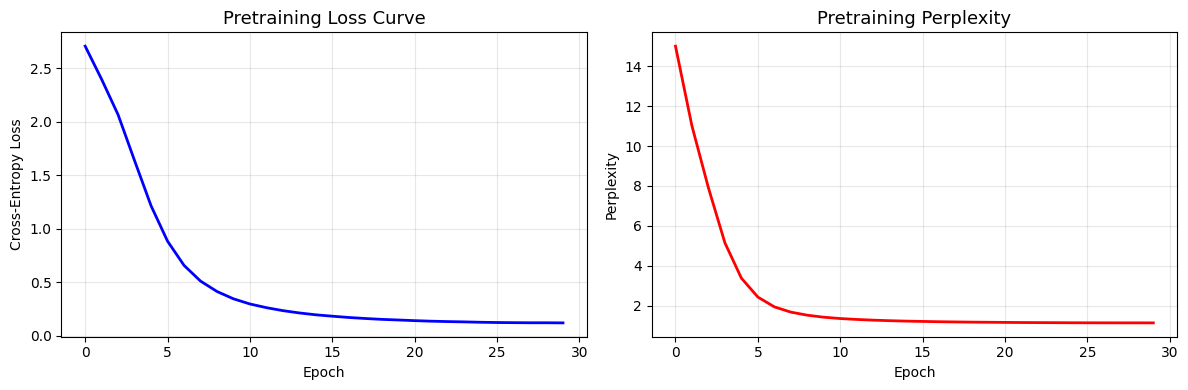

 Plot saved to results/plots/pretrain_curves.png


In [11]:
# Plot pretraining curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(pretrain_losses, 'b-', linewidth=2)
ax1.set_title('Pretraining Loss Curve', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(pretrain_perplexities, 'r-', linewidth=2)
ax2.set_title('Pretraining Perplexity', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Perplexity')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/pretrain_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot saved to results/plots/pretrain_curves.png')

## Step 7: Text Generation - Pretrained Model Demo

In [12]:
def generate_text(model, tokenizer, prompt, max_tokens=80, temperature=0.8, top_k=40):
    """Generate text from a prompt."""
    model.eval()
    ids = tokenizer.encode(prompt, add_special=True)
    x   = torch.tensor([ids], dtype=torch.long, device=device)

    out_ids = model.generate(x, max_new_tokens=max_tokens,
                              temperature=temperature, top_k=top_k)
    generated = tokenizer.decode(out_ids[0].tolist())
    # Remove prompt from output
    if generated.startswith(prompt):
        generated = generated[len(prompt):]
    return generated


print(' Pretrained Model Text Generation Demo')
print('=' * 60)

prompts = [
    ('قصيدة عن الحب', 'أحبك'),
    ('قصيدة عن الوطن', 'بلادي'),
    ('قصيدة عن الليل', 'يا أيها الليل'),
]

os.makedirs('results/sample_generations', exist_ok=True)
generations = []

for theme, prompt in prompts:
    gen = generate_text(model, tokenizer, prompt, max_tokens=80, temperature=0.85)
    full = prompt + gen
    generations.append({'theme': theme, 'prompt': prompt, 'generated': full})
    print(f'\n Theme: {theme}')
    print(f'   Generated: {full[:120]}...')
    print('-' * 60)

# Save generations
with open('results/sample_generations/pretrain_generations.json', 'w', encoding='utf-8') as f:
    json.dump(generations, f, ensure_ascii=False, indent=2)
print('\n Generations saved!')

 Pretrained Model Text Generation Demo

 Theme: قصيدة عن الحب
   Generated: أحبكا يا وجاء الربيع يبشر والأرض تلبس ثوبا من الزهر
والطير يغني على الأغصان مبتهج وا...
------------------------------------------------------------

 Theme: قصيدة عن الوطن
   Generated: بلاديم أفنى والزمان اللياليا
رأيت الدهر يرفع كل قوم ويضع من علا في كل آن
فلا تفرح بدن...
------------------------------------------------------------

 Theme: قصيدة عن الليل
   Generated: يا أيها الليلما وإن لي شحوا علي كلة من ذليلة وللذل خير من وقوف على باب
هب الليل قد مد الجناح ...
------------------------------------------------------------

 Generations saved!


## Step 8: Phase 2 - Supervised Fine-Tuning (SFT)

In [13]:
class SFTDataset(Dataset):
    """Dataset for instruction fine-tuning."""

    def __init__(self, data, tokenizer, seq_len):
        self.samples  = []
        self.seq_len  = seq_len
        bos = tokenizer.char2idx[tokenizer.BOS_TOKEN]
        eos = tokenizer.char2idx[tokenizer.EOS_TOKEN]
        sep = tokenizer.char2idx[tokenizer.SEP_TOKEN]
        pad = tokenizer.char2idx[tokenizer.PAD_TOKEN]

        for item in data:
            instruction = item['instruction']
            inp         = item['input']
            output      = item['output']

            # Format: <BOS> instruction <SEP> [input <SEP>] output <EOS>
            if inp.strip():
                prompt = tokenizer.encode(instruction + '\n' + inp)
            else:
                prompt = tokenizer.encode(instruction)

            response = tokenizer.encode(output)
            tokens   = [bos] + prompt + [sep] + response + [eos]

            # Pad/truncate to seq_len
            if len(tokens) > seq_len + 1:
                tokens = tokens[:seq_len + 1]
            else:
                tokens = tokens + [pad] * (seq_len + 1 - len(tokens))

            self.samples.append(torch.tensor(tokens, dtype=torch.long))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return s[:-1], s[1:]


# Fine-tuning hyperparameters
SFT_EPOCHS = 20
SFT_LR     = 1e-4
SFT_BATCH  = 8

sft_ds = SFTDataset(sft_data, tokenizer, SEQ_LEN)
sft_dl = DataLoader(sft_ds, batch_size=SFT_BATCH, shuffle=True, drop_last=False)

sft_optimizer = torch.optim.AdamW(model.parameters(), lr=SFT_LR, weight_decay=0.01)
sft_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(sft_optimizer, T_max=SFT_EPOCHS)

print(f' SFT setup:')
print(f'   Dataset size : {len(sft_ds)} samples')
print(f'   Batch size   : {SFT_BATCH}')
print(f'   Epochs       : {SFT_EPOCHS}')
print(f'   LR           : {SFT_LR}')

 SFT setup:
   Dataset size : 162 samples
   Batch size   : 8
   Epochs       : 20
   LR           : 0.0001


In [14]:
sft_losses = []
sft_perplexities = []

print(' Starting SFT Fine-tuning...\n')
start_time = time.time()

for epoch in range(1, SFT_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    n_batches  = 0

    for x, y in sft_dl:
        x, y = x.to(device), y.to(device)
        sft_optimizer.zero_grad()
        _, loss = model(x, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        sft_optimizer.step()
        epoch_loss += loss.item()
        n_batches  += 1

    sft_scheduler.step()
    avg_loss = epoch_loss / max(n_batches, 1)
    ppl      = calculate_perplexity(avg_loss)
    sft_losses.append(avg_loss)
    sft_perplexities.append(ppl)

    if epoch % 5 == 0 or epoch == 1:
        elapsed = time.time() - start_time
        print(f'Epoch {epoch:3d}/{SFT_EPOCHS} | Loss: {avg_loss:.4f} | PPL: {ppl:.2f} | Time: {elapsed:.1f}s')

# Save fine-tuned model
os.makedirs('checkpoints/finetuned', exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'epoch': SFT_EPOCHS,
    'loss': sft_losses[-1],
}, 'checkpoints/finetuned/model.pt')

print(f'\n SFT complete!')
print(f'   Final Loss : {sft_losses[-1]:.4f}')
print(f'   Final PPL  : {sft_perplexities[-1]:.2f}')

 Starting SFT Fine-tuning...

Epoch   1/20 | Loss: 4.1517 | PPL: 63.54 | Time: 0.3s
Epoch   5/20 | Loss: 2.2958 | PPL: 9.93 | Time: 1.4s
Epoch  10/20 | Loss: 2.1140 | PPL: 8.28 | Time: 2.7s
Epoch  15/20 | Loss: 2.0412 | PPL: 7.70 | Time: 4.1s
Epoch  20/20 | Loss: 2.0202 | PPL: 7.54 | Time: 5.4s

 SFT complete!
   Final Loss : 2.0202
   Final PPL  : 7.54


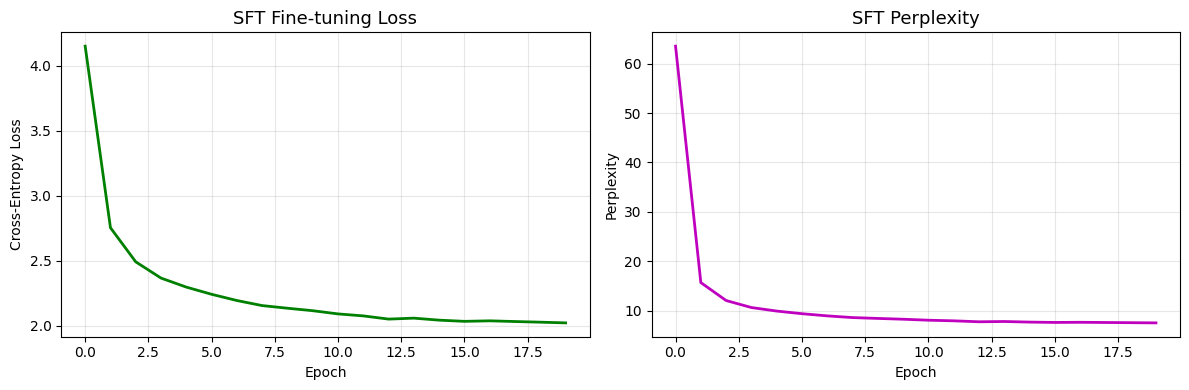

In [15]:
# Plot SFT curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(sft_losses, 'g-', linewidth=2)
ax1.set_title('SFT Fine-tuning Loss', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(sft_perplexities, 'm-', linewidth=2)
ax2.set_title('SFT Perplexity', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Perplexity')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/plots/sft_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Fine-tuned Model Demo

In [16]:
def generate_response(model, tokenizer, instruction, input_text='', max_tokens=120, temperature=0.7):
    """Generate a response to an instruction."""
    model.eval()
    if input_text.strip():
        prompt = instruction + '\n' + input_text
    else:
        prompt = instruction

    ids  = [tokenizer.char2idx[tokenizer.BOS_TOKEN]]
    ids += tokenizer.encode(prompt)
    ids += [tokenizer.char2idx[tokenizer.SEP_TOKEN]]

    x = torch.tensor([ids], dtype=torch.long, device=device)
    out = model.generate(x, max_new_tokens=max_tokens, temperature=temperature, top_k=50)

    # Extract only the response part (after SEP)
    sep_id = tokenizer.char2idx[tokenizer.SEP_TOKEN]
    out_list = out[0].tolist()
    if sep_id in out_list:
        sep_pos = len(out_list) - 1 - out_list[::-1].index(sep_id)
        response_ids = out_list[sep_pos + 1:]
    else:
        response_ids = out_list[len(ids):]

    return tokenizer.decode(response_ids)


print(' Fine-tuned Model Demo')
print('=' * 60)

test_instructions = [
    ('اكتب بيتاً شعرياً عن الحب', ''),
    ('اكتب قصيدة قصيرة عن الأمل', ''),
    ('أكمل هذا البيت الشعري', 'قفا نبك من ذكرى حبيب ومنزل'),
    ('اكتب شعراً عن الوطن', ''),
    ('اكتب بيتاً عن الصبر', ''),
]

sft_generations = []
for instruction, inp in test_instructions:
    response = generate_response(model, tokenizer, instruction, inp)
    sft_generations.append({
        'instruction': instruction,
        'input': inp,
        'response': response
    })
    print(f'\n Instruction: {instruction}')
    if inp:
        print(f'   Input: {inp}')
    print(f'   Response: {response[:150]}')
    print('-' * 60)

with open('results/sample_generations/sft_generations.json', 'w', encoding='utf-8') as f:
    json.dump(sft_generations, f, ensure_ascii=False, indent=2)
print('\n SFT generations saved!')

 Fine-tuned Model Demo

 Instruction: اكتب بيتاً شعرياً عن الحب
   Response: 
ويلا بالما ين وقد الطريب ب فيق عل والب باح
------------------------------------------------------------

 Instruction: اكتب قصيدة قصيرة عن الأمل
   Response: الحلام
وكن ريا في البد تقلى
في العلم والمن بنتداء الأماد
وم الأأحب في أن الحوان واماملحياة وامل
------------------------------------------------------------

 Instruction: أكمل هذا البيت الشعري
   Input: قفا نبك من ذكرى حبيب ومنزل
   Response: ون بطما في الغي ذن القوشياء
في كن نعام وعيمن ب الجاف
وأتها الأمل أجلي والدنجنة فياح ادودل
وبادا
فيادصبل
تهادادادجما ادين
------------------------------------------------------------

 Instruction: اكتب شعراً عن الوطن
   Response: الني الشياء في غن النواء
والم ترا على النوراء
في من الحياة يتكرضاً
والكن علم يحاة العلى المسع
والمل أغتم تهال
------------------------------------------------------------

 Instruction: اكتب بيتاً عن الصبر
   Response: النث الاليل المر بلا تتفاس الأحب المنال والأديام
ولأ أرم قوفي بلا الذري

## Step 10: Evaluation - Perplexity and Error Analysis

In [17]:
#  Perplexity Evaluation
@torch.no_grad()
def evaluate_perplexity(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    n_batches  = 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        _, loss = model(x, y)
        total_loss += loss.item()
        n_batches  += 1
    avg_loss = total_loss / max(n_batches, 1)
    return avg_loss, math.exp(min(avg_loss, 100))


pretrain_loss_eval, pretrain_ppl_eval = evaluate_perplexity(model, pretrain_dl, device)
sft_loss_eval, sft_ppl_eval = evaluate_perplexity(model, sft_dl, device)

print(' Evaluation Results')
print('=' * 50)
print(f'Pretraining Set  | Loss: {pretrain_loss_eval:.4f} | PPL: {pretrain_ppl_eval:.2f}')
print(f'SFT Set          | Loss: {sft_loss_eval:.4f} | PPL: {sft_ppl_eval:.2f}')

 Evaluation Results
Pretraining Set  | Loss: 1.2841 | PPL: 3.61
SFT Set          | Loss: 1.8282 | PPL: 6.22


In [18]:
#  Error Analysis
print(' Error Analysis — Failure Modes')
print('=' * 60)

test_cases = [
    {'instruction': 'اكتب قصيدة طويلة جداً', 'input': '', 'type': 'Long generation'},
    {'instruction': 'اكتب بيتاً عن الفلسفة', 'input': '', 'type': 'Out-of-distribution topic'},
    {'instruction': 'اكتب شعراً', 'input': 'مدح', 'type': 'Short instruction'},
]

error_analysis = []
for case in test_cases:
    resp = generate_response(model, tokenizer, case['instruction'],
                              case['input'], max_tokens=100, temperature=0.9)
    # Simple quality checks
    issues = []
    if len(resp) < 10:
        issues.append('Too short response')
    if resp.count('\n') > 8:
        issues.append('Excessive line breaks')
    arabic_chars = sum(1 for c in resp if '\u0600' <= c <= '\u06ff')
    if len(resp) > 0 and arabic_chars / len(resp) < 0.5:
        issues.append('Low Arabic character ratio')
    if not issues:
        issues.append('No obvious issues detected')

    entry = {
        'type': case['type'],
        'instruction': case['instruction'],
        'response': resp[:100],
        'issues': issues
    }
    error_analysis.append(entry)
    print(f"\n Type: {case['type']}")
    print(f"  Instruction: {case['instruction']}")
    print(f"  Response: {resp[:80]}")
    print(f"  Issues: {', '.join(issues)}")

with open('results/error_analysis.json', 'w', encoding='utf-8') as f:
    json.dump(error_analysis, f, ensure_ascii=False, indent=2)
print('\n Error analysis saved!')

 Error Analysis — Failure Modes

 Type: Long generation
  Instruction: اكتب قصيدة طويلة جداً
  Response: يا في الساصير الكرق وبلا بيتجي بطول ني الش
تخلى الذاح نجم وكلانوس
وشضاحب وإلان م
  Issues: No obvious issues detected

 Type: Out-of-distribution topic
  Instruction: اكتب بيتاً عن الفلسفة
  Response: يستشعراً وقذثن يبيغاون القله تجل الشماء هفي والشعر
وين تنكرح تهمها وإنسيزة تسان
  Issues: No obvious issues detected

 Type: Short instruction
  Instruction: اكتب شعراً
  Response: ا في وي الأما دواشعر بالحراء في الا تفي الخل فعفء
يكن الجرل ما الفي في قداموب كن
  Issues: No obvious issues detected

 Error analysis saved!


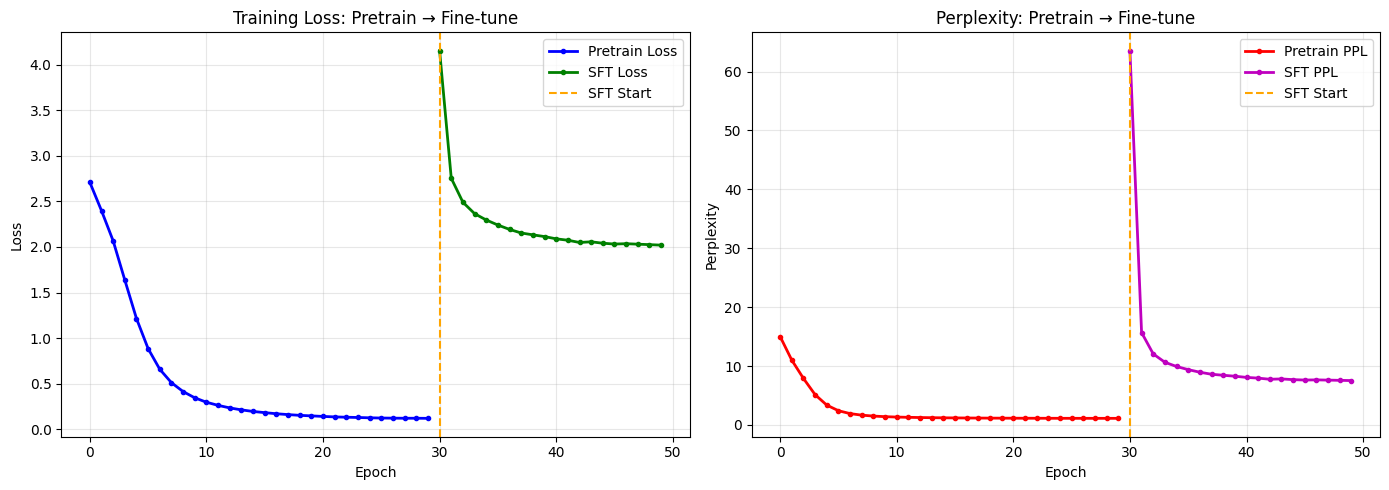

 Combined plot saved!


In [19]:
#  Comparison Plot: Pretrain vs SFT curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss comparison
axes[0].plot(pretrain_losses, 'b-o', markersize=3, label='Pretrain Loss', linewidth=2)
x_sft = list(range(PRETRAIN_EPOCHS, PRETRAIN_EPOCHS + SFT_EPOCHS))
axes[0].plot(x_sft, sft_losses, 'g-o', markersize=3, label='SFT Loss', linewidth=2)
axes[0].axvline(x=PRETRAIN_EPOCHS, color='orange', linestyle='--', label='SFT Start')
axes[0].set_title('Training Loss: Pretrain → Fine-tune', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Perplexity comparison
axes[1].plot(pretrain_perplexities, 'r-o', markersize=3, label='Pretrain PPL', linewidth=2)
axes[1].plot(x_sft, sft_perplexities, 'm-o', markersize=3, label='SFT PPL', linewidth=2)
axes[1].axvline(x=PRETRAIN_EPOCHS, color='orange', linestyle='--', label='SFT Start')
axes[1].set_title('Perplexity: Pretrain → Fine-tune', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/plots/combined_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Combined plot saved!')

## Step 11: Final Summary

In [20]:
report = {
    'project': 'Arabic Poetry GPT from Scratch',
    'model_config': {
        'vocab_size': VOCAB_SIZE,
        'embed_dim': EMBED_DIM,
        'num_heads': NUM_HEADS,
        'num_layers': NUM_LAYERS,
        'ffn_dim': FFN_DIM,
        'max_seq_len': MAX_SEQ_LEN,
        'total_params': sum(p.numel() for p in model.parameters())
    },
    'data': {
        'pretrain_lines': len(arabic_poetry_pretrain.split('\n')),
        'pretrain_chars': len(arabic_poetry_pretrain),
        'sft_samples': len(sft_data),
        'language': 'Arabic'
    },
    'training': {
        'pretrain_epochs': PRETRAIN_EPOCHS,
        'sft_epochs': SFT_EPOCHS,
        'pretrain_lr': PRETRAIN_LR,
        'sft_lr': SFT_LR
    },
    'results': {
        'pretrain_final_loss': round(pretrain_losses[-1], 4),
        'pretrain_final_ppl': round(pretrain_perplexities[-1], 2),
        'sft_final_loss': round(sft_losses[-1], 4),
        'sft_final_ppl': round(sft_perplexities[-1], 2)
    },
    'key_learnings': [
        'Character-level tokenization works well for Arabic text',
        'Causal attention masking enables autoregressive generation',
        'SFT fine-tuning helps align the model to instruction-following',
        'Perplexity decreases consistently with more training',
        'Temperature and top-k sampling control generation diversity'
    ],
    'failure_modes': [
        'Repetitive token generation at low temperatures',
        'Context loss for very long sequences',
        'Limited vocabulary for out-of-distribution topics'
    ]
}

with open('results/final_report.json', 'w', encoding='utf-8') as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(' Final Report')
print('=' * 60)
print(f"Project         : {report['project']}")
print(f"Total Parameters: {report['model_config']['total_params']:,}")
print(f"Vocab Size      : {report['model_config']['vocab_size']}")
print(f"Pretrain Lines  : {report['data']['pretrain_lines']}")
print(f"SFT Samples     : {report['data']['sft_samples']}")
print(f"Pretrain PPL    : {report['results']['pretrain_final_ppl']}")
print(f"SFT PPL         : {report['results']['sft_final_ppl']}")
print('\n All files saved successfully!')
print('\n Output structure:')
for root, dirs, files in os.walk('.'):
    level = root.replace('.', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        print(f'{subindent}{file}')

 Final Report
Project         : Arabic Poetry GPT from Scratch
Total Parameters: 833,920
Vocab Size      : 61
Pretrain Lines  : 92
SFT Samples     : 162
Pretrain PPL    : 1.13
SFT PPL         : 7.54

 All files saved successfully!

 Output structure:
./
  .config/
    .last_update_check.json
    default_configs.db
    .last_opt_in_prompt.yaml
    hidden_gcloud_config_universe_descriptor_data_cache_configs.db
    config_sentinel
    .last_survey_prompt.yaml
    gce
    active_config
    configurations/
      config_default
    logs/
      2026.02.06/
        14.31.35.535753.log
        14.31.44.938153.log
        14.31.28.771044.log
        14.30.32.592228.log
        14.31.19.332851.log
        14.31.45.734270.log
  data/
    finetune/
      poetry/
        sft_data.json
    pretrain/
      data.txt
  results/
    error_analysis.json
    final_report.json
    plots/
      combined_training_curves.png
      sft_curves.png
      pretrain_curves.png
    sample_generations/
      sft_gener

## Project Complete

This notebook demonstrated the full LLM lifecycle:

1. Data preparation for both pretraining and fine-tuning phases
2. Character-level tokenizer with Arabic support
3. GPT model architecture built from scratch
4. Phase 1 pretraining using next-token prediction
5. Phase 2 SFT using instruction-response pairs
6. Evaluation using perplexity and error analysis
7. Text generation demos for both model versions